# Import libs and read data

In [1]:

import warnings
import pandas as pd
warnings.filterwarnings("ignore", category=pd.errors.PerformanceWarning)
warnings.filterwarnings("ignore", category=RuntimeWarning)
import os
import pandas as pd

from Strong_hierarchical_lasso.libs_cb_lasso.Helpers_lasso import *
from sklearn.metrics import r2_score





#Load data

base_path = "../../..//KMFM_main_paper/Data/Data_Buchwald_Hartwig_amination"
filename_xtrain = "xtrain.csv.gz"
filename_xtest = "xtest.csv.gz"
filename_xall = "xxxxall.csv.gz"
filename_ytrain = "ytrain.csv"
filename_ytest = "ytest.csv"
filename_yall = "yall.csv"

X_train = pd.read_csv(os.path.join(base_path,filename_xtrain),  compression="gzip").to_numpy()
X_test = pd.read_csv(os.path.join(base_path,filename_xtest),  compression="gzip").to_numpy()
X_all = pd.read_csv(os.path.join(base_path,filename_xall),  compression="gzip").to_numpy()
y_train = pd.read_csv(os.path.join(base_path,filename_ytrain)).to_numpy().ravel()  
y_test = pd.read_csv(os.path.join(base_path,filename_ytest)).to_numpy().ravel()
y_all = pd.read_csv(os.path.join(base_path,filename_yall)).to_numpy().ravel()







# Lasso test set performance 


Trying lambda: 5e-05
Train R² = 0.9846, Val R² = 0.8618

Trying lambda: 0.0001
Train R² = 0.9661, Val R² = 0.8961

Trying lambda: 0.0005
Train R² = 0.8900, Val R² = 0.8786

Trying lambda: 0.001
Train R² = 0.8446, Val R² = 0.8457

Trying lambda: 0.005
Train R² = 0.6173, Val R² = 0.6177

Best λ on validation: 0.0001 (Val R² = 0.8961)

Final Test R² = 0.8835

 Final Test RMSE: 0.09


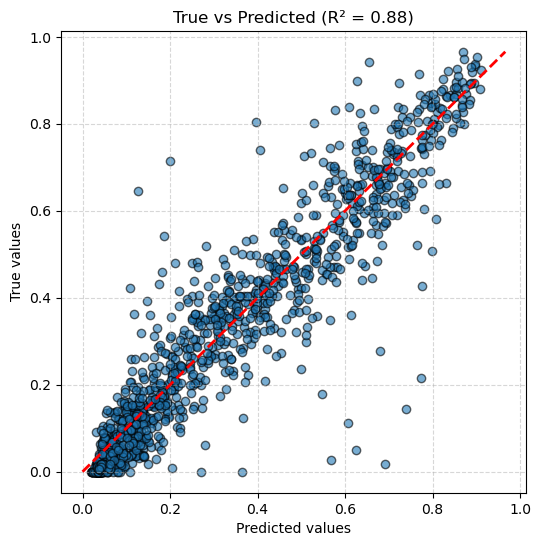

(array([ 2.92497681, -0.89366281, -2.63485976, ..., -0.        ,
       -0.        ,  0.        ]), -6.216559867641099, 0.0001, 0.883513125283946, [(5e-05, 0.9845875124452866, 0.8618372958673473), (0.0001, 0.9661425605525072, 0.8960623797470094), (0.0005, 0.8900026643533845, 0.8785672160792204), (0.001, 0.8445676587846933, 0.8457297338976505), (0.005, 0.6173022362003933, 0.6176861971303926)])


In [2]:
# Do grid search on train val split of train set and see performance on test set
results=grid_search_lasso(
    X_train, X_test, y_train, y_test,
    lambda_grid=[5e-5, 1e-4, 5e-4, 1e-3, 5e-3],
    maxit=10,
    tol=0.5,
    sd_tol=1e-6,
    val_size=0.3,
    random_state=42,
    plot=True
)

print(results)



# Access best coefs 

In [3]:
best_coefs = results[0]
best_intercept = results[1]
pred_test = kappa1(X_test@best_coefs+best_intercept)
print("R2 socore on test set: ", r2_score(y_test, pred_test))

print("lasso coefs: ",best_coefs)
print("intercept: ", best_intercept)


R2 socore on test set:  0.883513125283946
lasso coefs:  [ 2.92497681 -0.89366281 -2.63485976 ... -0.         -0.
  0.        ]
intercept:  -6.216559867641099
